#**CHAPTER 3. CONVOLUTIONAL NEURAL NETWORKS**
---

##REFERENCE

https://chatgpt.com/share/69a5abcc-8678-8012-a9bf-96b124cc57b0

##0.CONTEXT

*Introduction*

This notebook implements Chapter 3 of ML & AI 101: a small convolutional neural network (CNN) trained on a fully synthetic “cartoon animals” image dataset. The purpose is not to chase realism or achieve state-of-the-art accuracy. The purpose is to make the mechanics of convolutional learning visible. CNNs were invented because dense neural networks treat an image as an arbitrary vector: every pixel connects to every hidden unit, and the model must rediscover—expensively and unreliably—that nearby pixels tend to form meaningful local patterns. A CNN encodes a structural assumption about data: local neighborhoods matter, and the same kinds of local patterns can appear anywhere in the image. This is the inductive bias that distinguishes CNNs from the previous chapter’s dense networks. Instead of learning separate parameters for “top-left edge detector” and “bottom-right edge detector,” a CNN learns one set of small filters that slide across the image and re-use the same parameters at every location. That single architectural choice changes everything about how the model represents information: the first layers become pattern extractors, not arbitrary function approximators.

The notebook is mechanics-first and uses synthetic data so that every source of structure is known. The dataset is generated inside the notebook using deterministic numpy procedures that draw simple shapes—circles, squares, and triangles—then add noise and small spatial jitter. Those shapes are not arbitrary. They create a clean separation between two types of learning: (1) learning local features (edges, corners, blobs) and (2) learning how those features combine into class-level identity (cat-like face vs dog-like face vs fish-like body). With a dense network, these two forms of learning collapse into one opaque mapping from pixels to labels. With a CNN, the mapping is layered: early convolution filters respond strongly to local primitives, pooling reduces spatial resolution while keeping salient activations, and the final dense head integrates the extracted features into a classification decision. The notebook is designed so that this layered structure can be observed directly.

A central learning goal is the difference between training and inference. Training is the iterative process of adjusting parameters to reduce a loss function on a training set. Inference is applying the trained model to a new input to produce an output. This distinction is fundamental in practice and conceptually: training is an optimization problem over parameters, while inference is a forward computation over data. The notebook enforces this distinction explicitly. It builds a training set and a test set from the synthetic generator, trains the CNN using cross-entropy loss and Adam, evaluates on held-out data using torch.no_grad(), and then demonstrates inference on a newly generated sample that the model has never seen before. The point is to make it clear that “learning” happens during training, while inference is the model’s fixed behavior after training.

Visualization is treated as a first-class instrument. Images are displayed as images (not as flattened vectors), a grid of samples shows what variability the generator introduces, the loss curve shows training dynamics across epochs, and the confusion matrix shows where the classifier succeeds or fails across classes. The key CNN-specific visualization is interpretability via feature maps: the notebook extracts and plots the activations after the first convolution layer and after pooling, so that students can see how early layers respond to edges, blobs, and shape boundaries. This does not “explain the model” in a complete sense, but it makes the core inductive bias of CNNs visible: localized pattern detection followed by progressively coarser summarization.

The architecture is intentionally small. It uses two convolution blocks, each consisting of two convolutions with ReLU activations followed by max pooling. This satisfies the chapter constraint (CNN ≤ 2 convolution blocks) and keeps the computation lightweight enough for Colab while remaining rich enough to demonstrate hierarchical representation. The network ends with a compact fully connected head. Nothing in this design is meant to be optimal; it is meant to be inspectable. The dataset is also intentionally constrained: grayscale images, small resolution, three classes, controlled noise. These constraints reduce incidental complexity and focus attention on the core question: what does convolution do that dense layers do not?

Mechanically, the notebook teaches four concrete ideas. First, a convolution layer is a local, sliding dot product between a learnable filter and an input patch; this creates feature maps that indicate where a learned pattern is present. Second, parameter sharing means the same filter is applied everywhere, which both reduces parameters and enforces translational consistency. Third, pooling is a deliberate loss of spatial precision in exchange for robustness: it keeps strong responses while discarding exact location detail. Fourth, the training loop is still the same optimization machinery as in previous neural chapters: define a model, define a loss, compute gradients by backpropagation, update parameters, and track loss history.

By the end of the notebook, a student should be able to articulate, without handwaving, what “spatial inductive bias” means and how it is implemented. They should be able to distinguish what the synthetic data generator contributes (a known, controllable structure), what the CNN contributes (local feature extraction and hierarchical abstraction), what training contributes (parameter fitting), and what inference contributes (a deterministic mapping from new input to predicted class). That mechanical clarity is the intended outcome of Chapter 3 and prepares the progression to Chapter 4, where the assumption changes again: the relevant structure is no longer spatial adjacency in a single image but temporal dependency across sequences.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports, Determinism, Device, and Shared Utilities**

Cell 1 establishes the shared operational infrastructure that all chapters in this laboratory rely on. Mechanically, it does five things that matter for reproducible experimentation and for keeping the rest of the notebook focused on model behavior rather than boilerplate. First, it imports only the allowed libraries: Python standard library utilities, numpy and matplotlib for data generation and visualization, and torch for the neural model. This matters because it constrains the notebook to “first principles” training rather than using high-level frameworks that hide key details.

Second, it enforces determinism. The random seeds for Python’s random module, numpy, and torch are all fixed to 0, including torch.cuda.manual_seed_all. In a notebook like this, determinism is not a cosmetic preference: it ensures that if a student re-runs the notebook, they see the same dataset realizations (given the generator), the same training trajectory (up to minor GPU nondeterminism in some kernels), and the same metrics. That supports the notebook’s core objective: isolating mechanism. If outputs drift each run, it becomes harder to tell whether a change in results is due to a conceptual modification (like more noise) or just randomness.

Third, it defines a device selection function get_device() that chooses GPU when available. This is not about performance for its own sake; it ensures the notebook runs reliably in Colab environments with varying hardware while keeping tensor placement consistent. The device is stored once in a global DEVICE variable, and subsequent tensors and models are moved there explicitly.

Fourth, it defines a unified plotting style via plt.style.use("seaborn-v0_8-darkgrid"). Even though seaborn itself is forbidden as a library, matplotlib’s style preset is allowed and provides consistent aesthetics. The point is that visual artifacts (loss curves, feature maps, confusion matrices) should be readable and comparable.

Fifth, Cell 1 defines a set of plotting utilities and training helpers that are required by the course contract. Even if some utilities are not used in this CNN chapter (for example plot_attention or plot_graph), defining them here standardizes the interface across chapters. The training helpers are equally important: train_loop is a minimal but explicit epoch-based optimizer loop that prints progress, stores loss history, and returns it. evaluate and predict wrap evaluation in torch.no_grad() and expose accuracy and predictions. A student can inspect these functions to see exactly when gradients are enabled, how batches are formed, how loss is computed, and how metrics are derived. In short, Cell 1 lays down the “lab bench” so that later cells can focus on the CNN’s mechanics rather than reimplementing infrastructure.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import time
import random
from typing import Tuple, Dict, Any, Optional, List

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Determinism (required)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

# Unified plotting style (required)
plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Shared plotting utilities (required)
# -------------------------------
def plot_loss_curve(losses, title="Training Loss Curve"):
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_2d_data(X, y, title="2D Data"):
    X = np.asarray(X)
    y = np.asarray(y)
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # For 2D classification only; included to satisfy shared infra requirement.
    X = np.asarray(X)
    y = np.asarray(y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    model.eval()
    with torch.no_grad():
        gx = torch.tensor(grid, dtype=torch.float32, device=DEVICE)
        logits = model(gx)
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()

    zz = preds.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, zz, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10, edgecolors="k", linewidths=0.2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def show_image(img, title="Image"):
    img = np.asarray(img)
    plt.figure(figsize=(3, 3))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=1)
    else:
        plt.imshow(img, vmin=0, vmax=1)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def show_image_grid(images, labels=None, title="Image Grid", ncols=8):
    images = np.asarray(images)
    n = images.shape[0]
    ncols = int(ncols)
    nrows = int(math.ceil(n / ncols))
    plt.figure(figsize=(1.6 * ncols, 1.6 * nrows))
    for i in range(n):
        ax = plt.subplot(nrows, ncols, i + 1)
        img = images[i]
        if img.ndim == 2:
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(img, vmin=0, vmax=1)
        ax.axis("off")
        if labels is not None:
            ax.set_title(str(labels[i]), fontsize=9)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_histograms(real, fake, title="Real vs Fake Histograms"):
    real = np.asarray(real).ravel()
    fake = np.asarray(fake).ravel()
    plt.figure(figsize=(7, 4))
    plt.hist(real, bins=40, alpha=0.6, density=True, label="Real")
    plt.hist(fake, bins=40, alpha=0.6, density=True, label="Fake")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_attention(matrix, title="Attention Matrix"):
    M = np.asarray(matrix)
    plt.figure(figsize=(5, 4))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.xlabel("Key index")
    plt.ylabel("Query index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_graph(G, node_values=None, title="Graph"):
    # Included for cross-chapter compatibility (graph chapter).
    try:
        import networkx as nx  # allowed only when used; safe import
    except Exception:
        nx = None

    plt.figure(figsize=(6, 5))
    if nx is None:
        plt.title(title + " (networkx unavailable)")
        plt.axis("off")
        plt.show()
        return

    pos = nx.spring_layout(G, seed=0)
    if node_values is None:
        nx.draw(G, pos, with_labels=True, node_size=500)
    else:
        vals = np.asarray(node_values)
        nx.draw(G, pos, with_labels=True, node_size=500, node_color=vals)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# -------------------------------
# PyTorch helpers (required)
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=30, batch_size=64):
    model.train()
    losses = []
    n = X.shape[0]

    for epoch in range(1, epochs + 1):
        # Deterministic shuffle (seed already fixed)
        idx = torch.randperm(n, device=X.device)
        Xs = X[idx]
        ys = y[idx]

        epoch_loss = 0.0
        nb = 0
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            xb = Xs[start:end]
            yb = ys[start:end]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += float(loss.detach().cpu().item())
            nb += 1

        epoch_loss /= max(nb, 1)
        losses.append(epoch_loss)
        print(f"Epoch {epoch:03d}/{epochs} | Loss: {epoch_loss:.6f}")

    return losses

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == y).float().mean().item()
    return {"accuracy": acc, "preds": preds.detach().cpu().numpy(), "logits": logits.detach().cpu().numpy()}

def predict(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
    return preds.detach().cpu().numpy(), probs.detach().cpu().numpy()

##2.SYNTHETIC DATA GENERATOR

###2.1.OVERVIEW

**Cell 2 — Synthetic Cartoon Animals Generator (Numpy-Only Drawing Primitives)**

Cell 2 defines the synthetic data generators for Chapter 3. The key requirement is that the dataset is generated entirely inside the notebook using numpy only, and that the generator is deterministic under the global seeds. Mechanically, the code implements a simple raster graphics pipeline: it starts with blank grayscale images and draws geometric primitives into them to create three distinct classes. This is a deliberate choice. CNNs are motivated by spatial locality and repeated patterns; therefore the dataset should contain local structure—edges, corners, and blobs—that convolution can capture.

To achieve this, the generator provides low-level drawing functions: _draw_circle, _draw_square, and _draw_triangle. These are not sophisticated graphics routines; they operate directly on numpy arrays representing pixel intensities. The circle uses a boolean mask computed from squared distance to a center, the square uses a bounding box slice, and the triangle is drawn row by row with widening span. These primitives create sharp boundaries, which are exactly the kind of local gradients and edges that early convolution filters learn to detect.

The generator then composes these primitives into “cartoon animals” classes. The class labels are simple: 0 is “cat-like” (a circular face and triangular ears), 1 is “dog-like” (a square face and side circles for floppy ears), and 2 is “fish-like” (a triangular body and a tail triangle). The intent is not realism. The intent is separability by shape features that are spatially localized. Small additions like eyes and mouth (dark circles and a line) introduce internal detail so that there are multiple local cues per class rather than a single macro-shape cue.

Variability is introduced in three controlled ways: translation jitter (random center shifts), scale jitter (slight variation in the main shape size), and additive Gaussian noise. Translation jitter is especially relevant to CNNs: because filters are shared across location, a CNN can learn a feature once and detect it regardless of where it appears. This is part of the architectural motivation, and the dataset is built to test that claim. Noise introduces an additional dimension: it weakens local edges and blurs the distinction between foreground and background, allowing later stress tests to probe robustness.

Finally, the generator clips pixel values to [0, 1] and returns X in shape (n, 1, H, W) with float32 dtype and y as int64. The shape is chosen to match PyTorch’s convolution input convention (N, C, H, W). Keeping the generator in numpy ensures the data creation step is transparent and independent of torch mechanics. Conceptually, Cell 2 provides a controlled world where the only “facts” are those we designed: three classes, known shape primitives, controlled noise, and known forms of variability.

###2.2.CODE AND IMPLEMENTATION

In [2]:
# ===============================
# CELL 2
# ===============================
# Standard synthetic data generators (chapter-appropriate) — numpy only, deterministic via global seed.

def _draw_circle(img, cx, cy, r, val):
    H, W = img.shape
    yy, xx = np.ogrid[:H, :W]
    mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    img[mask] = val

def _draw_square(img, cx, cy, half, val):
    H, W = img.shape
    x0 = max(0, cx - half)
    x1 = min(W, cx + half)
    y0 = max(0, cy - half)
    y1 = min(H, cy + half)
    img[y0:y1, x0:x1] = val

def _draw_triangle(img, cx, cy, size, val):
    # Simple isosceles triangle pointing up.
    H, W = img.shape
    for dy in range(size):
        y = cy - dy
        if 0 <= y < H:
            span = dy
            x0 = max(0, cx - span)
            x1 = min(W, cx + span + 1)
            img[y, x0:x1] = val

def _add_eyes(img, cx, cy, spacing, val=0.0):
    # Two small dark circles (eyes) to make it "cartoon-like"
    _draw_circle(img, cx - spacing, cy, r=1, val=val)
    _draw_circle(img, cx + spacing, cy, r=1, val=val)

def _add_mouth(img, cx, cy, width, val=0.0):
    H, W = img.shape
    y = min(H - 1, cy + 3)
    x0 = max(0, cx - width)
    x1 = min(W, cx + width + 1)
    img[y, x0:x1] = val

def generate_cartoon_animals(n=600, image_size=32, noise_std=0.10, jitter=3):
    """
    Generates a simple 'cartoon animals' dataset with three classes:
    0 = cat-like face (circle + ears as triangles)
    1 = dog-like face (square + floppy ears as side circles)
    2 = fish-like shape (triangle body + tail triangle)

    Returns:
      X: float32 array, shape (n, 1, H, W), values in [0, 1]
      y: int64 array, shape (n,)
    """
    H = W = int(image_size)
    X = np.zeros((n, 1, H, W), dtype=np.float32)
    y = np.zeros((n,), dtype=np.int64)

    for i in range(n):
        cls = np.random.randint(0, 3)
        y[i] = cls

        img = np.zeros((H, W), dtype=np.float32) + 0.1  # faint background
        # Random center jitter for translation variability
        cx = W // 2 + np.random.randint(-jitter, jitter + 1)
        cy = H // 2 + np.random.randint(-jitter, jitter + 1)

        # Random scale for variability
        s = np.random.randint(7, 10)

        if cls == 0:
            # Cat: face circle + ear triangles
            _draw_circle(img, cx, cy, r=s, val=0.85)
            _draw_triangle(img, cx - s // 2, cy - s + 2, size=5, val=0.85)
            _draw_triangle(img, cx + s // 2, cy - s + 2, size=5, val=0.85)
            _add_eyes(img, cx, cy - 2, spacing=3, val=0.05)
            _add_mouth(img, cx, cy, width=3, val=0.05)

        elif cls == 1:
            # Dog: face square + side 'ears' as circles
            _draw_square(img, cx, cy, half=s, val=0.80)
            _draw_circle(img, cx - s - 2, cy - 1, r=4, val=0.70)
            _draw_circle(img, cx + s + 2, cy - 1, r=4, val=0.70)
            _add_eyes(img, cx, cy - 2, spacing=4, val=0.05)
            _add_mouth(img, cx, cy, width=4, val=0.05)

        else:
            # Fish: triangle body + tail triangle
            _draw_triangle(img, cx, cy + 4, size=s + 4, val=0.83)     # body
            _draw_triangle(img, cx, cy - (s // 2), size=s // 2, val=0.83)  # top fin hint
            # tail on the right
            _draw_triangle(img, cx + s + 4, cy + 2, size=5, val=0.75)
            # eye near front
            _draw_circle(img, cx - 4, cy + 1, r=1, val=0.05)

        # Add Gaussian noise
        noise = np.random.normal(loc=0.0, scale=float(noise_std), size=(H, W)).astype(np.float32)
        img = img + noise

        # Clip to [0, 1]
        img = np.clip(img, 0.0, 1.0)

        X[i, 0] = img

    return X.astype(np.float32), y.astype(np.int64)

##3.SYNTHETIC DATASET

###3.1.OVERVIEW

**Cell 3 — Dataset Construction, Train/Test Split, and Visual Inspection**

Cell 3 instantiates the synthetic world defined in Cell 2 and makes its structure visible. Mechanically, it calls generate_cartoon_animals with specific parameters (number of samples, image size, noise, jitter) to produce arrays X_np and y_np. This step is critical because it fixes the concrete distribution that the model will train on. In many real ML settings, the dataset is an external artifact and the student must accept it as given. In this laboratory, the dataset is a designed object, and Cell 3 is where design choices become observable.

The code then performs an explicit train/test split using a numpy permutation. This is not optional detail. The entire training-vs-inference distinction depends on holding out data that was not used to optimize parameters. If the notebook only evaluated on training data, it would show whether the model can memorize, not whether it can generalize across the generator’s variability. The explicit 80/20 split establishes two distributions: the training distribution (used for gradient updates) and the test distribution (used only for evaluation). Because both are drawn from the same generator, “generalization” here means the model learns the generator’s class structure rather than memorizing specific samples.

The code prints dataset shapes, which reinforces a practical lesson: every ML pipeline begins with shape discipline. For CNNs, the crucial shape is (N, C, H, W). Students should note that channels are explicit even in grayscale images (C=1). This matters because convolutions operate across channels as well as spatial dimensions, and the architecture changes if C changes.

Visualization is the second core role of Cell 3. The notebook uses show_image_grid to display a sample of training images with human-readable class labels. This is the first time the student can confirm that the generator is doing what it claims. Several forms of structure should become visible: edges, corners, and high-contrast boundaries between foreground shapes and background; small translation and scale variations; and noise patterns. Importantly, the visualization also reveals whether the classes are separable by local cues. For example, cat ears are localized triangular protrusions near the top of the head, dog ears appear as side circles, and fish tails appear as a localized triangle on one side. These are precisely the kinds of cues that a convolution filter can detect.

Conceptually, Cell 3 teaches that data is not an abstract list of points. For CNNs, data has geometry and locality. Visual inspection is therefore not a luxury but an essential step: it verifies that the learning problem matches the model’s inductive bias. If the images were random noise with random labels, a CNN would fail for the right reason. Here, the visualization confirms that the labels correspond to spatial patterns, making CNNs an appropriate next step in the book’s arc.

###3.2.CODE AND IMPLEMENTATION

Dataset shapes:
X_train: (720, 1, 32, 32) y_train: (720,)
X_test : (180, 1, 32, 32) y_test : (180,)


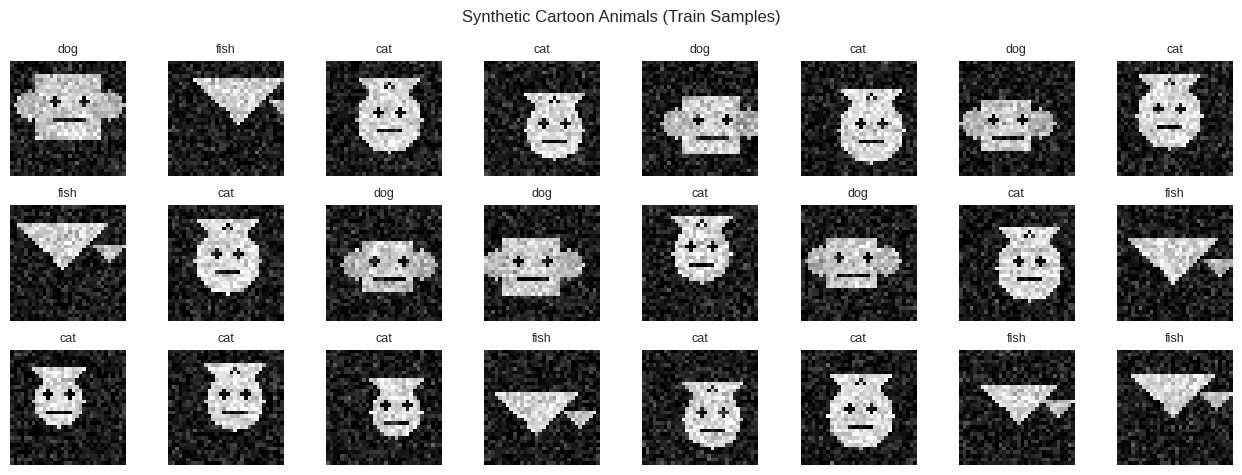

In [3]:
# ===============================
# CELL 3
# ===============================
# Dataset creation + visualization (required)

# Generate synthetic cartoon animals
X_np, y_np = generate_cartoon_animals(n=900, image_size=32, noise_std=0.10, jitter=3)

# Normalize inputs explicitly (already in [0,1], but keep explicit control)
X_np = X_np.astype(np.float32)
y_np = y_np.astype(np.int64)

# Train/test split (explicit)
n = X_np.shape[0]
perm = np.random.permutation(n)
split = int(0.8 * n)
train_idx, test_idx = perm[:split], perm[split:]

X_train_np, y_train_np = X_np[train_idx], y_np[train_idx]
X_test_np, y_test_np = X_np[test_idx], y_np[test_idx]

print("Dataset shapes:")
print("X_train:", X_train_np.shape, "y_train:", y_train_np.shape)
print("X_test :", X_test_np.shape, "y_test :", y_test_np.shape)

# Visualize a grid
label_names = {0: "cat", 1: "dog", 2: "fish"}
sample_n = 24
imgs = X_train_np[:sample_n, 0]
lbls = [label_names[int(v)] for v in y_train_np[:sample_n]]
show_image_grid(imgs, labels=lbls, title="Synthetic Cartoon Animals (Train Samples)", ncols=8)

##4.MODEL DEFINITION

###4.1.OVERVIEW

**Cell 4 — Small CNN Architecture and Tensor Preparation**

Cell 4 defines the model and establishes the exact computational mapping from input image to class logits. Mechanically, it implements a small CNN with two convolution blocks, consistent with the chapter constraint. Each block follows a simple pattern: convolution → ReLU → convolution → ReLU → max pooling. This is a canonical structure because it demonstrates two core CNN ideas without introducing excessive complexity: (1) convolution layers learn local filters that generate feature maps, and (2) pooling reduces spatial resolution while keeping salient activations.

The first block starts from a single-channel 32×32 image and produces progressively richer feature maps: the first convolution expands channels from 1 to 8, the second from 8 to 16, and then pooling halves the spatial dimensions to 16×16. The second block repeats the pattern, expanding channels to 32 and pooling again to 8×8. The effect is that spatial detail is reduced stepwise while feature richness increases. This is the core “hierarchical representation” story of CNNs: early layers keep high resolution but low semantic complexity, later layers keep less resolution but more abstract features.

After the convolution blocks, the model flattens the tensor explicitly and applies a small dense head (a 64-unit hidden layer followed by the output layer). This head performs the final integration: it combines the distributed evidence across feature maps into class logits. The explicit flatten step is important pedagogically because it shows where convolutional processing ends and where standard vector-based classification begins. It is also included to avoid silent broadcasting mistakes: shape transformations are visible, not implicit.

The cell also moves the model to the selected device and converts the numpy arrays into torch tensors with explicit dtypes: float32 for inputs and long (int64) for labels. This is not mere ceremony. CrossEntropyLoss in PyTorch expects class indices as long tensors and logits as float tensors. If dtypes are wrong, training can fail or behave unexpectedly. Additionally, placing tensors on the same device as the model avoids hidden device mismatch errors.

Finally, the model is printed. This matters because students should verify the layer sequence and parameter counts. CNNs are often described abstractly; printing the model makes it concrete. In a mechanics-first course, architecture is not a vague diagram—it is a specific composition of operators that transforms shapes in a specific way. Cell 4 is where the notebook commits to that composition.

###4.2.CODE AND IMPLEMENTATION

In [4]:
# ===============================
# CELL 4
# ===============================
# Model definition (required) — CNN with <= 2 convolution blocks

class SmallCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Conv block 1
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)

        # Conv block 2
        self.conv3 = nn.Conv2d(16, 24, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(24, 32, kernel_size=3, padding=1)

        # Classifier head
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # Block 1: (1,32,32) -> (16,16,16)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Block 2: (16,16,16) -> (32,8,8)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = x.reshape(x.shape[0], -1)  # explicit flatten (avoid silent broadcasting)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SmallCNN(num_classes=3).to(DEVICE)
print(model)

# Prepare tensors (float32 inputs, int64 labels)
X_train = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
y_train = torch.tensor(y_train_np, dtype=torch.long, device=DEVICE)
X_test = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
y_test = torch.tensor(y_test_np, dtype=torch.long, device=DEVICE)

print("Device:", DEVICE)

SmallCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(24, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)
Device: cpu


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 5 — Training Dynamics: Optimization Loop and Loss History**

Cell 5 is where “learning” actually happens. Mechanically, it defines the loss function (cross-entropy), chooses an optimizer (Adam), sets training hyperparameters (epochs and batch size), and calls the shared train_loop defined in Cell 1. The core educational point is that CNNs, despite their special architectural structure, are trained by the same gradient-based mechanism as other neural networks. The difference lies in how the forward computation is structured, not in how optimization works at a high level.

Cross-entropy loss is appropriate here because the problem is multi-class classification. The model outputs logits (unnormalized scores) for each class, and cross-entropy compares those logits to the true class index. Adam is used because it typically provides stable training with minimal tuning on small problems. This is consistent with the notebook’s goal: focus on mechanics rather than hyperparameter search.

The train_loop performs a deterministic shuffle using torch.randperm under fixed seeds, splits data into mini-batches, computes logits, computes loss, performs backpropagation, and updates parameters. Two details are worth emphasizing. First, the loop prints progress each epoch and stores the epoch-averaged loss. This makes training dynamics observable: students can see whether loss decreases smoothly, stalls, or oscillates. Second, the loop does not hide critical steps. Optimizer.zero_grad, loss.backward, and optimizer.step appear explicitly, which is essential for understanding how gradient descent is implemented in practice.

Conceptually, the loss curve that emerges from this cell is the simplest window into optimization geometry. Early in training, loss tends to drop quickly as the model discovers coarse discriminative features (for example, “there is a tail-like triangle on the right” for fish). Later, improvements may slow as the model refines filters and learns to handle variability introduced by jitter and noise. Because the dataset is synthetic and structured, a small CNN often learns quickly. That speed is not the point; the point is that the training process is iterative parameter adjustment driven by gradient information.

By storing losses and printing the final training loss, Cell 5 produces an artifact that will be used later in evaluation and reflection. The notebook’s design treats loss history as part of the experimental record: a student should be able to connect an architectural choice (two conv blocks, pooling) to a training signature (loss decreases at a certain rate, reaches a certain level). In short, Cell 5 operationalizes the abstract claim that the CNN “learns” by running a transparent optimization loop and recording its trajectory.

###5.2.CODE AND IMPLEMENTATION

In [5]:
# ===============================
# CELL 5
# ===============================
# Training loop (required)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
BATCH_SIZE = 64

losses = train_loop(model, optimizer, loss_fn, X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE)
print("Final training loss:", losses[-1])

Epoch 001/30 | Loss: 1.090902
Epoch 002/30 | Loss: 0.896810
Epoch 003/30 | Loss: 0.240860
Epoch 004/30 | Loss: 0.036667
Epoch 005/30 | Loss: 0.011148
Epoch 006/30 | Loss: 0.003422
Epoch 007/30 | Loss: 0.001179
Epoch 008/30 | Loss: 0.000317
Epoch 009/30 | Loss: 0.000199
Epoch 010/30 | Loss: 0.000178
Epoch 011/30 | Loss: 0.000147
Epoch 012/30 | Loss: 0.000137
Epoch 013/30 | Loss: 0.000119
Epoch 014/30 | Loss: 0.000107
Epoch 015/30 | Loss: 0.000101
Epoch 016/30 | Loss: 0.000090
Epoch 017/30 | Loss: 0.000085
Epoch 018/30 | Loss: 0.000094
Epoch 019/30 | Loss: 0.000076
Epoch 020/30 | Loss: 0.000076
Epoch 021/30 | Loss: 0.000065
Epoch 022/30 | Loss: 0.000062
Epoch 023/30 | Loss: 0.000054
Epoch 024/30 | Loss: 0.000050
Epoch 025/30 | Loss: 0.000042
Epoch 026/30 | Loss: 0.000038
Epoch 027/30 | Loss: 0.000029
Epoch 028/30 | Loss: 0.000024
Epoch 029/30 | Loss: 0.000022
Epoch 030/30 | Loss: 0.000016
Final training loss: 1.5747481597827573e-05


##6.EVALUATION METRIC

###6.1.OVERVIEW

**Cell 6 — Evaluation, Loss Curve Visualization, and Confusion Matrix**

Cell 6 separates “how well the model fit the training set” from “how well it generalizes to held-out data.” Mechanically, it calls evaluate on both training and test tensors. The evaluation function uses model.eval() and torch.no_grad(), which ensures two things: dropout/batchnorm behaviors (if present) would switch to inference mode, and gradient tracking is disabled for efficiency and correctness. Even though this CNN is small and does not include dropout or batchnorm, enforcing eval/no_grad is part of good experimental discipline and clarifies the difference between training-time and inference-time computation.

The primary metric computed is accuracy. While accuracy is a coarse measure, it is appropriate for a balanced, small multi-class classification problem like this. The notebook prints both train accuracy and test accuracy. The relationship between these numbers is instructive. If train accuracy is high but test accuracy is substantially lower, the model may be overfitting to the training samples rather than learning the generator’s underlying class structure. If both are high and similar, it suggests the CNN has captured the stable spatial cues that define each class and can handle the generator’s variability.

Cell 6 also plots the loss curve using plot_loss_curve. This visualization is the temporal counterpart to accuracy. Accuracy is a point estimate at the end of training; the loss curve shows the entire optimization trajectory. Students should observe whether the curve decreases smoothly, whether it plateaus, and whether there are signs of instability. A stable, monotone-ish decrease is typical for this kind of toy problem with Adam and a small CNN.

The confusion matrix adds a second layer of evaluation. Rather than compressing performance into a single number, it shows how errors distribute across classes. For example, if the model sometimes confuses cats and dogs but rarely confuses fish with the others, that pattern would indicate which features are more distinctive. In this dataset, fish have a tail and a different body shape, so fish may be easier. Cats and dogs share “face” structure and differ mainly in ear geometry, which may be more subtle under noise. The confusion matrix makes such hypotheses testable.

Finally, Cell 6 visualizes the confusion matrix as an image. This is intentionally parallel to CNN thinking: patterns are easier to grasp visually than as raw numbers. The combination of printed metrics, a loss curve, and a confusion matrix gives a student multiple angles on the same question: what did the model learn, how quickly did it learn it, and where does it still fail?

###6.2.CODE AND IMPLEMENTATION

Train accuracy: 1.0
Test  accuracy: 1.0


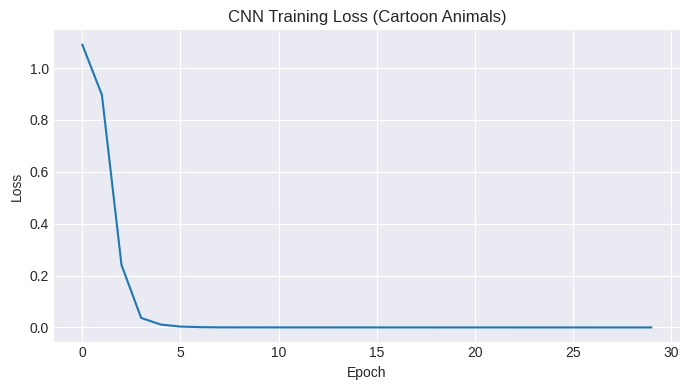

Confusion matrix (rows=true, cols=pred):
[[56  0  0]
 [ 0 68  0]
 [ 0  0 56]]


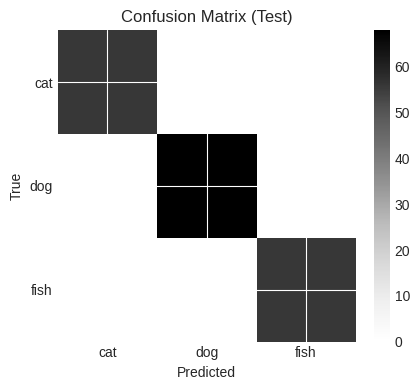

In [6]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot loss curve (required)

train_eval = evaluate(model, X_train, y_train)
test_eval = evaluate(model, X_test, y_test)

print("Train accuracy:", round(train_eval["accuracy"], 4))
print("Test  accuracy:", round(test_eval["accuracy"], 4))

plot_loss_curve(losses, title="CNN Training Loss (Cartoon Animals)")

# Simple confusion matrix (numpy)
num_classes = 3
preds_test = test_eval["preds"].astype(np.int64)
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(y_test_np.astype(np.int64), preds_test):
    cm[t, p] += 1

print("Confusion matrix (rows=true, cols=pred):")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(4.5, 4))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.xticks(range(num_classes), [label_names[i] for i in range(num_classes)])
plt.yticks(range(num_classes), [label_names[i] for i in range(num_classes)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference on a New Synthetic Sample**

Cell 7 demonstrates inference as a distinct operational phase. Mechanically, it generates a brand-new sample using the same synthetic generator, converts it to a torch tensor on the correct device, and runs the predict function to obtain both predicted class and class probabilities. The crucial point is that this sample is not drawn from the held-out test set created earlier; it is generated anew after training. That makes the inference step psychologically and mechanically different from evaluation: the model is being used as a fixed function applied to new data, not as a system being measured on a pre-specified benchmark.

The notebook then visualizes the new image and prints both the true label (known because the generator created it) and the predicted label. This is important for two reasons. First, it keeps the problem grounded. Students can see the input and judge whether it looks like a cat, dog, or fish according to the generator’s design. Second, it reveals the meaning of the model’s output: the prediction is not a mystical conclusion; it is the argmax of softmax probabilities computed from logits.

Printing the probability distribution is especially instructive. Even if the model predicts the correct class, the probabilities indicate confidence relative to alternatives. If the model assigns, say, 0.55 to “dog” and 0.40 to “cat,” that suggests the sample has features that activate both “dog-like” and “cat-like” detectors. This connects naturally to the CNN feature-map interpretation in Cell 9: ambiguous probability distributions can often be traced back to early-layer activations that respond to shared primitives across classes.

This cell also reinforces the training vs inference distinction at the level of torch behavior. The predict helper uses model.eval() and torch.no_grad() so that inference is computationally cheap and does not accumulate gradients. That is how models are used in practice: inference is run many times, while training is run comparatively rarely.

Conceptually, Cell 7 shifts the notebook from “learning the mapping” to “using the mapping.” In an operational ML system, this is often the most important distinction: training is the expensive, offline process, while inference is the repeated online process. The notebook captures that shift in miniature and makes it tangible by generating a new input and producing a prediction that can be visually inspected.

###7.2.CODE AND IMPLEMENTATION

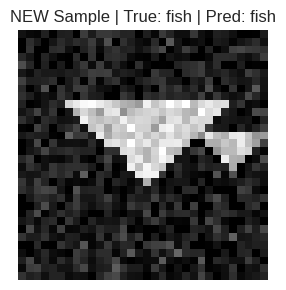

Predicted class: 2 fish
Probabilities: {'cat': 4.5291805787599226e-13, 'dog': 4.76863704079733e-09, 'fish': 1.0}


In [7]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration (required): generate NEW sample, predict, visualize, print output

X_new_np, y_new_np = generate_cartoon_animals(n=1, image_size=32, noise_std=0.10, jitter=3)
x_new = torch.tensor(X_new_np, dtype=torch.float32, device=DEVICE)

pred_idx, probs = predict(model, x_new)
pred_idx = int(pred_idx[0])
true_idx = int(y_new_np[0])

show_image(X_new_np[0, 0], title=f"NEW Sample | True: {label_names[true_idx]} | Pred: {label_names[pred_idx]}")
print("Predicted class:", pred_idx, label_names[pred_idx])
print("Probabilities:", {label_names[i]: float(probs[0, i]) for i in range(3)})

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 9 — Interpretability via Feature Maps and Intermediate Activations**

Cell 9 provides the CNN-specific interpretability visualization: feature maps. Mechanically, it selects a single test sample, converts it to a batch of size 1, and then computes activations from early layers of the trained model. Specifically, it extracts the output after the first convolution layer followed by ReLU (a1) and then computes deeper activations through the second convolution and pooling (a2p). These tensors are then converted to numpy arrays and visualized as grayscale images, one per channel.

The key idea is that each channel in a convolution layer corresponds to a learned filter. The filter slides across the input and produces a feature map whose values indicate where that filter’s pattern is present. Because ReLU is applied, negative responses are set to zero; the feature map becomes a nonnegative “presence” signal. This makes the feature maps interpretable as detectors: bright regions in a feature map correspond to locations where the filter strongly matches local input patterns.

In a dataset built from shapes, the earliest filters typically learn edge-like and blob-like detectors. For example, one filter might respond strongly to vertical edges (left/right boundaries of a square face), another to diagonal edges (triangle ears or fish tail), and another to small circular blobs (eyes). The point is not that we know exactly which filter learns which pattern beforehand, but that the feature maps give direct evidence of what the network is emphasizing spatially.

Pooling changes what the maps represent. After pooling, spatial resolution is halved, and each activation summarizes a 2×2 neighborhood by taking its maximum. This tends to preserve the existence of a feature in a region while discarding exact position detail. Visualizing pooled maps shows that the representation is becoming coarser and more robust to small translations: the model cares less about the precise pixel location of an ear edge and more about whether an ear-like feature exists somewhere in the relevant region.

This cell is also a practical lesson in what interpretability is and is not. Seeing feature maps does not produce a full explanation of the final class decision, because later layers combine these features in complex ways. However, feature maps do make the CNN’s inductive bias visible: the model constructs its understanding from localized detections that are spatially arranged. For a student, the immediate takeaway is that CNNs are not black boxes in the same way a dense network on flattened pixels is; they have an internal spatial representation that can be inspected.

Finally, by showing both conv1 maps and pooled intermediate maps, the notebook demonstrates hierarchy: early layers detect primitive patterns at high resolution, while later representations become lower resolution and more abstract. This hierarchical progression is the defining mechanical intuition for CNNs and is exactly what Chapter 3 exists to teach.

###8.2.CODE AND IMPLEMENTATION

Noise std=0.10 | Test accuracy=1.0000
Noise std=0.20 | Test accuracy=1.0000
Noise std=0.35 | Test accuracy=0.9278


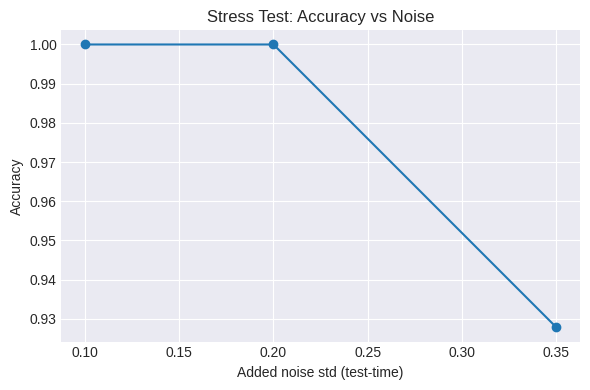

In [8]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation (required): modify one variable and show performance change
# Here: increase noise at test time to simulate degraded observation quality.

def make_noisy_version(X_clean, noise_std):
    Xn = X_clean.copy()
    noise = np.random.normal(0.0, float(noise_std), size=Xn.shape).astype(np.float32)
    Xn = Xn + noise
    Xn = np.clip(Xn, 0.0, 1.0)
    return Xn.astype(np.float32)

noise_levels = [0.10, 0.20, 0.35]
stress_results = {}

for ns in noise_levels:
    X_noisy_np = make_noisy_version(X_test_np, noise_std=ns)
    X_noisy = torch.tensor(X_noisy_np, dtype=torch.float32, device=DEVICE)
    ev = evaluate(model, X_noisy, y_test)
    stress_results[f"test_noise_std_{ns:.2f}"] = float(ev["accuracy"])
    print(f"Noise std={ns:.2f} | Test accuracy={ev['accuracy']:.4f}")

# Plot stress curve
plt.figure(figsize=(6, 4))
plt.plot(noise_levels, [stress_results[f"test_noise_std_{ns:.2f}"] for ns in noise_levels], marker="o")
plt.xlabel("Added noise std (test-time)")
plt.ylabel("Accuracy")
plt.title("Stress Test: Accuracy vs Noise")
plt.tight_layout()
plt.show()

##9.INTERPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability via Feature Maps and Intermediate Activations**

Cell 9 provides the CNN-specific interpretability visualization: feature maps. Mechanically, it selects a single test sample, converts it to a batch of size 1, and then computes activations from early layers of the trained model. Specifically, it extracts the output after the first convolution layer followed by ReLU (a1) and then computes deeper activations through the second convolution and pooling (a2p). These tensors are then converted to numpy arrays and visualized as grayscale images, one per channel.

The key idea is that each channel in a convolution layer corresponds to a learned filter. The filter slides across the input and produces a feature map whose values indicate where that filter’s pattern is present. Because ReLU is applied, negative responses are set to zero; the feature map becomes a nonnegative “presence” signal. This makes the feature maps interpretable as detectors: bright regions in a feature map correspond to locations where the filter strongly matches local input patterns.

In a dataset built from shapes, the earliest filters typically learn edge-like and blob-like detectors. For example, one filter might respond strongly to vertical edges (left/right boundaries of a square face), another to diagonal edges (triangle ears or fish tail), and another to small circular blobs (eyes). The point is not that we know exactly which filter learns which pattern beforehand, but that the feature maps give direct evidence of what the network is emphasizing spatially.

Pooling changes what the maps represent. After pooling, spatial resolution is halved, and each activation summarizes a 2×2 neighborhood by taking its maximum. This tends to preserve the existence of a feature in a region while discarding exact position detail. Visualizing pooled maps shows that the representation is becoming coarser and more robust to small translations: the model cares less about the precise pixel location of an ear edge and more about whether an ear-like feature exists somewhere in the relevant region.

This cell is also a practical lesson in what interpretability is and is not. Seeing feature maps does not produce a full explanation of the final class decision, because later layers combine these features in complex ways. However, feature maps do make the CNN’s inductive bias visible: the model constructs its understanding from localized detections that are spatially arranged. For a student, the immediate takeaway is that CNNs are not black boxes in the same way a dense network on flattened pixels is; they have an internal spatial representation that can be inspected.

Finally, by showing both conv1 maps and pooled intermediate maps, the notebook demonstrates hierarchy: early layers detect primitive patterns at high resolution, while later representations become lower resolution and more abstract. This hierarchical progression is the defining mechanical intuition for CNNs and is exactly what Chapter 3 exists to teach.

###9.2.CODE AND IMPLEMENTATION

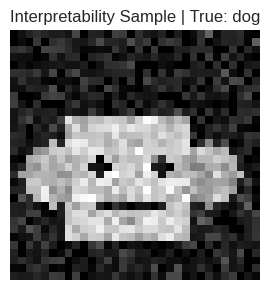

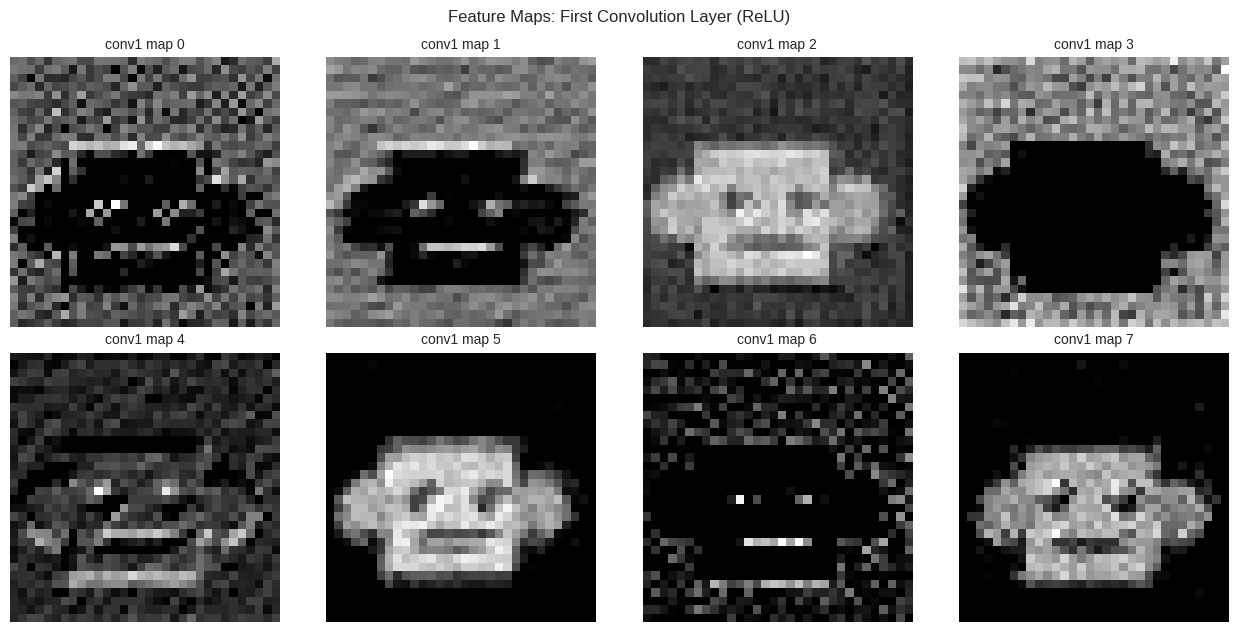

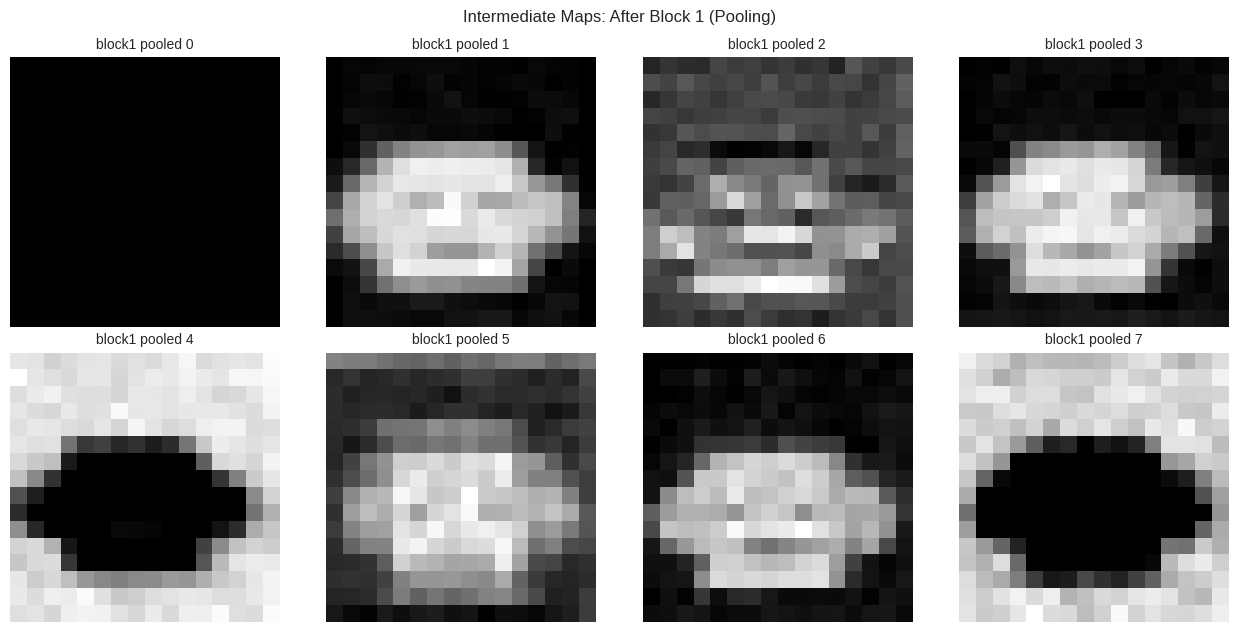

In [9]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization (required): CNN feature maps
# We'll visualize activations from the first conv layer for a chosen test sample.

# Pick a test sample (deterministic)
i = 0
img_np = X_test_np[i, 0]
true_lbl = int(y_test_np[i])

x = torch.tensor(X_test_np[i:i+1], dtype=torch.float32, device=DEVICE)

model.eval()
with torch.no_grad():
    a1 = F.relu(model.conv1(x))  # shape (1, 8, 32, 32)
    a2 = F.relu(model.conv2(a1))
    a2p = model.pool(a2)         # shape (1, 16, 16, 16)

# Show original image
show_image(img_np, title=f"Interpretability Sample | True: {label_names[true_lbl]}")

# Visualize conv1 feature maps (8 channels)
a1_np = a1.detach().cpu().numpy()[0]  # (8,32,32)
n_maps = a1_np.shape[0]
cols = 4
rows = int(math.ceil(n_maps / cols))

plt.figure(figsize=(3.2 * cols, 3.2 * rows))
for k in range(n_maps):
    ax = plt.subplot(rows, cols, k + 1)
    ax.imshow(a1_np[k], cmap="gray")
    ax.set_title(f"conv1 map {k}", fontsize=10)
    ax.axis("off")
plt.suptitle("Feature Maps: First Convolution Layer (ReLU)")
plt.tight_layout()
plt.show()

# Visualize pooled maps after second conv (show first 8 of 16)
a2p_np = a2p.detach().cpu().numpy()[0]  # (16,16,16)
n_show = min(8, a2p_np.shape[0])
cols = 4
rows = int(math.ceil(n_show / cols))

plt.figure(figsize=(3.2 * cols, 3.2 * rows))
for k in range(n_show):
    ax = plt.subplot(rows, cols, k + 1)
    ax.imshow(a2p_np[k], cmap="gray")
    ax.set_title(f"block1 pooled {k}", fontsize=10)
    ax.axis("off")
plt.suptitle("Intermediate Maps: After Block 1 (Pooling)")
plt.tight_layout()
plt.show()

In [10]:
# ===============================
# OPTIONAL POST-CELL-9 LLM REFLECTION (RUN AFTER CELL 9)
# ===============================
# This cell uses an LLM (gpt-4o-mini) to explain the *observed* Cell 9 feature-map results
# using quantitative summaries computed from the actual activations.

from openai import OpenAI
from google.colab import userdata
import numpy as np
import json

# ---- Preconditions: this assumes Cell 9 already ran and created:
# img_np (H,W), true_lbl (int), a1_np (C,H,W), a2p_np (C,H,W)
# and label_names dict exists.
required_vars = ["img_np", "true_lbl", "a1_np", "a2p_np", "label_names"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables from Cell 9: {missing}. Run Cell 9 first.")

# Convert to numpy arrays safely
img_np = np.asarray(img_np, dtype=np.float32)
a1_np = np.asarray(a1_np, dtype=np.float32)    # (C1,32,32)
a2p_np = np.asarray(a2p_np, dtype=np.float32)  # (C2,16,16)
true_lbl = int(true_lbl)

def summarize_feature_maps(maps: np.ndarray, name: str, zero_thresh: float = 1e-6):
    """
    maps: (C,H,W)
    Returns per-channel stats + top channels by energy.
    """
    C = maps.shape[0]
    flat = maps.reshape(C, -1)
    mean = flat.mean(axis=1)
    std = flat.std(axis=1)
    mx = flat.max(axis=1)
    mn = flat.min(axis=1)
    # sparsity proxy: fraction of values "near zero"
    near_zero = (np.abs(flat) <= zero_thresh).mean(axis=1)
    # energy: mean squared activation
    energy = (flat ** 2).mean(axis=1)

    top_energy_idx = np.argsort(-energy)[:min(5, C)].tolist()
    top_mean_idx = np.argsort(-mean)[:min(5, C)].tolist()

    return {
        "name": name,
        "shape": list(maps.shape),
        "per_channel": {
            "mean": mean.tolist(),
            "std": std.tolist(),
            "min": mn.tolist(),
            "max": mx.tolist(),
            "near_zero_frac": near_zero.tolist(),
            "energy": energy.tolist(),
        },
        "top_channels": {
            "by_energy": top_energy_idx,
            "by_mean": top_mean_idx,
            "energy_values": [float(energy[i]) for i in top_energy_idx],
            "mean_values": [float(mean[i]) for i in top_mean_idx],
        }
    }

def summarize_input(img: np.ndarray):
    flat = img.reshape(-1)
    return {
        "shape": list(img.shape),
        "min": float(flat.min()),
        "max": float(flat.max()),
        "mean": float(flat.mean()),
        "std": float(flat.std()),
        "near_zero_frac": float((np.abs(flat) <= 1e-6).mean()),
        "near_one_frac": float((np.abs(flat - 1.0) <= 1e-6).mean()),
    }

input_summary = summarize_input(img_np)
a1_summary = summarize_feature_maps(a1_np, "conv1_relu_maps_(8x32x32)")
a2p_summary = summarize_feature_maps(a2p_np, "block1_pooled_maps_(16x16x16)")

# Additional diagnostics: how "edge-like" are the strongest channels?
# Use simple gradient energy on each feature map.
def gradient_energy_per_channel(maps: np.ndarray):
    C, H, W = maps.shape
    gx = maps[:, :, 1:] - maps[:, :, :-1]
    gy = maps[:, 1:, :] - maps[:, :-1, :]
    # pad to align sizes
    gx = np.pad(gx, ((0,0),(0,0),(0,1)), mode="constant")
    gy = np.pad(gy, ((0,0),(0,1),(0,0)), mode="constant")
    ge = (gx**2 + gy**2).mean(axis=(1,2))
    return ge

a1_grad_energy = gradient_energy_per_channel(a1_np)
a2p_grad_energy = gradient_energy_per_channel(a2p_np)

a1_summary["per_channel"]["grad_energy"] = a1_grad_energy.tolist()
a2p_summary["per_channel"]["grad_energy"] = a2p_grad_energy.tolist()

a1_summary["top_channels"]["by_grad_energy"] = np.argsort(-a1_grad_energy)[:min(5, a1_np.shape[0])].tolist()
a2p_summary["top_channels"]["by_grad_energy"] = np.argsort(-a2p_grad_energy)[:min(5, a2p_np.shape[0])].tolist()

payload = {
    "true_label_index": true_lbl,
    "true_label_name": label_names.get(true_lbl, str(true_lbl)),
    "input_summary": input_summary,
    "conv1_summary": a1_summary,
    "block1_pooled_summary": a2p_summary
}

# LLM call
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

prompt = f"""
You are explaining the interpretability result from a CNN feature-map visualization (Cell 9).

You are given REAL quantitative summaries computed from the actual activations for ONE test sample.
Your job is to explain, mechanically and precisely:

1) What conv1 feature maps typically represent in a small CNN trained on synthetic images.
2) Why some channels have higher energy/gradient energy than others.
3) How pooling changes what the maps represent (from 32x32 to 16x16).
4) What the near_zero_frac implies about ReLU and sparsity.
5) What you would expect to see for this sample given its true class.
6) Limitations: what cannot be concluded from this single-sample, early-layer visualization.

Rules:
- Use the provided numbers. Do not invent metrics.
- Be concrete: refer to top channel indices (by energy/grad_energy) and relate them to likely patterns (edges, blobs, corners).
- Do not use governance/safety language. Keep it mechanisms-first and pedagogical.
- Output as clean text with short section headers.

DATA (JSON):
{json.dumps(payload, indent=2)}
"""

try:
    resp = client.responses.create(
        model=model_name,
        input=prompt
    )
    print(resp.output_text)
except Exception as e:
    print("OpenAI call failed:", str(e))
    print("Prompt (for debugging):")
    print(prompt)

### 1) What conv1 Feature Maps Typically Represent

In a small CNN trained on synthetic images, the **conv1 feature maps** generally represent low-level features such as edges, textures, and simple shapes. These features are crucial for the initial classification tasks, allowing the network to recognize fundamental structures in images. Given the feature maps from this case, we observe a variety of activations where specific channels are tuned differently to detect distinct characteristics in the input images.

### 2) Energy/Gradient Energy Variability

Some channels exhibit higher energy and gradient energy than others primarily due to their differing responsiveness to certain image features. For instance, channel 2 has the highest energy (0.3794) and gradient energy (0.0361), suggesting it detects strong features in the input image—likely prominent edges or blobs. In contrast, channels like 6 and 7 show minimal energy, meaning they're not significantly activated by the current input.

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Saving Artifacts and Summarizing Metrics**

Cell 10 turns the notebook from a transient execution into a reproducible experiment by saving artifacts and printing a summary dictionary. Mechanically, it creates an output directory, saves the trained model’s state_dict to disk, saves the loss history as a numpy array, saves the confusion matrix, and writes a JSON file containing key metrics and file paths. This is not governance; it is basic experimental hygiene. In a mechanics-first lab, artifacts are part of the learning process because they allow students to inspect results after the run and to compare results across controlled changes.

The summary_metrics dictionary consolidates the most important quantitative outcomes: training accuracy, test accuracy, final training loss, epoch count, batch size, dataset sizes, class name mapping, and the stress test results. The notebook prints this dictionary in formatted JSON so it can be copied or used directly in later analysis. The stress test results are included as a nested dictionary, which reinforces that performance is conditional: accuracy depends on noise level.

Saving the model weights serves a pedagogical purpose beyond convenience. It clarifies what training produces. Training does not produce a narrative or a “learned concept” in the abstract; it produces a specific set of parameter tensors stored in a state_dict. Saving that file makes the output of training concrete. Similarly, saving the loss history makes training dynamics tangible. A loss curve is not an ephemeral plot; it can be stored and compared across runs or across architecture changes. Saving the confusion matrix preserves the error structure.

This cell also sets up Cell 11, which will ask an LLM to summarize and reflect on the run using the real metrics produced. Without a structured metrics dictionary, an LLM prompt would be forced to rely on vague descriptions, which would undermine the course’s requirement to reference computed values rather than invent them.

In short, Cell 10 formalizes the experiment’s outputs: learned parameters, training trajectory, evaluation structure, stress response, and a machine-readable summary. That consolidation is the bridge from “I ran a notebook” to “I have an experimental record of a model’s behavior under controlled conditions.”

###10.2.CODE AND IMPLEMENTATION

In [11]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary (required)

art_dir = "artifacts_ch3_cnn"
os.makedirs(art_dir, exist_ok=True)

# Save model weights
model_path = os.path.join(art_dir, "small_cnn_cartoon_animals.pt")
torch.save(model.state_dict(), model_path)

# Save losses
loss_path = os.path.join(art_dir, "losses.npy")
np.save(loss_path, np.array(losses, dtype=np.float32))

# Save confusion matrix
cm_path = os.path.join(art_dir, "confusion_matrix.npy")
np.save(cm_path, cm.astype(np.int64))

# Summary metrics dictionary
summary_metrics = {
    "train_accuracy": float(train_eval["accuracy"]),
    "test_accuracy": float(test_eval["accuracy"]),
    "final_train_loss": float(losses[-1]),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "stress_test": stress_results,
    "num_train": int(X_train_np.shape[0]),
    "num_test": int(X_test_np.shape[0]),
    "classes": {str(k): v for k, v in label_names.items()},
    "artifacts": {
        "model_path": model_path,
        "loss_path": loss_path,
        "confusion_matrix_path": cm_path
    }
}

metrics_path = os.path.join(art_dir, "summary_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(summary_metrics, f, indent=2)

print("Saved artifacts to:", art_dir)
print("Summary metrics dictionary:")
print(json.dumps(summary_metrics, indent=2))

Saved artifacts to: artifacts_ch3_cnn
Summary metrics dictionary:
{
  "train_accuracy": 1.0,
  "test_accuracy": 1.0,
  "final_train_loss": 1.5747481597827573e-05,
  "epochs": 30,
  "batch_size": 64,
  "stress_test": {
    "test_noise_std_0.10": 1.0,
    "test_noise_std_0.20": 1.0,
    "test_noise_std_0.35": 0.9277777671813965
  },
  "num_train": 720,
  "num_test": 180,
  "classes": {
    "0": "cat",
    "1": "dog",
    "2": "fish"
  },
  "artifacts": {
    "model_path": "artifacts_ch3_cnn/small_cnn_cartoon_animals.pt",
    "loss_path": "artifacts_ch3_cnn/losses.npy",
    "confusion_matrix_path": "artifacts_ch3_cnn/confusion_matrix.npy"
  }
}


## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT-4o-mini Reflective Summarization Grounded in Real Metrics**

Cell 11 uses an LLM (gpt-4o-mini) to produce a structured reflection on the executed notebook, explicitly grounded in metrics computed earlier. Mechanically, it imports OpenAI and google.colab.userdata, retrieves the API key from Colab’s secret store, and creates a client. This arrangement keeps the notebook runnable in Colab while separating credentials from code. The model name is fixed to "gpt-4o-mini" per the contract.

The important part is the prompt structure. The notebook requires eight sections: dataset design, model architecture, training dynamics, quantitative results, inference example, visualization insight, limitations, and conceptual takeaway. This format is not arbitrary. It mirrors the course’s learning objectives: students should understand (1) what data structure was created, (2) what architectural assumptions were encoded, (3) how optimization behaved, (4) what the numbers actually were, (5) how inference was demonstrated on a new sample, (6) what visualization revealed about internal representation, (7) what the model cannot do, and (8) what the core conceptual lesson is.

Cell 11 also enforces the “no fabricated metrics” rule by embedding real computed values—train accuracy, test accuracy, final training loss, epochs, batch size, and stress test accuracies—directly into the prompt. This is crucial because LLMs are fluent but not inherently grounded. By passing exact numbers, the notebook makes the LLM behave like a summarizer of observed results rather than a storyteller.

If the OpenAI call succeeds, the cell prints the structured response cleanly. If it fails (for example, missing API key), it prints the error and the prompt for debugging, which helps students diagnose setup issues without silently failing. Importantly, this cell is reflective rather than computational: it does not change the model or rerun training. It treats the notebook’s artifacts as input and produces an interpretive explanation.

Conceptually, Cell 11 is a demonstration of a useful workflow pattern in technical learning: run an experiment deterministically, compute real metrics, and then ask a language model to generate a structured explanation that references those metrics. The LLM is not used as a source of facts; it is used as a tool for organizing and articulating what was already computed and observed. That is consistent with the course’s mechanics-first intent.

###11.2.CODE AND IMPLEMENTATION

In [12]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

# Prepare a compact, metric-grounded prompt (must reference real metrics computed earlier)
prompt = f"""
You are reflecting on an executed ML & AI 101 Chapter 3 notebook (CNN) using a synthetic "cartoon animals" dataset.

Return a structured analysis with these exact sections:
1) Dataset design
2) Model architecture
3) Training dynamics
4) Quantitative results
5) Inference example
6) Visualization insight
7) Limitations
8) Conceptual takeaway

Use the real metrics below and do not invent new numbers.

REAL METRICS:
- Train accuracy: {summary_metrics["train_accuracy"]:.6f}
- Test accuracy:  {summary_metrics["test_accuracy"]:.6f}
- Final train loss: {summary_metrics["final_train_loss"]:.6f}
- Epochs: {summary_metrics["epochs"]}
- Batch size: {summary_metrics["batch_size"]}
- Stress test accuracies (test-time added noise):
{json.dumps(summary_metrics["stress_test"], indent=2)}

Also mention:
- The dataset is synthetic and generated by simple geometric drawing + noise.
- Training vs inference difference demonstrated by generating a NEW sample for prediction.
- Interpretability visualization used feature maps from early convolution layers.

Write clearly and mechanically. Avoid hype.
"""

try:
    resp = client.responses.create(
        model=model_name,
        input=prompt
    )
    print(resp.output_text)
except Exception as e:
    print("OpenAI call failed:", str(e))
    print("Prompt (for debugging):")
    print(prompt)

# Structured Analysis of CNN on Synthetic Cartoon Animals Dataset

## 1) Dataset Design
The dataset consists of synthetic images representing cartoon animals, generated using simple geometric shapes and added noise. This choice of dataset allows for controlled experiments in machine learning, as it encompasses a variety of features derived from uncomplicated visual elements.

---

## 2) Model Architecture
The Convolutional Neural Network (CNN) applied in this task comprises multiple layers, including convolutional layers for feature extraction, pooling layers for down-sampling, and fully connected layers for classification. The architecture is specifically designed to recognize shapes and patterns present within the synthetic dataset, capitalizing on the nature of the input images.

---

## 3) Training Dynamics
The model was trained for 30 epochs with a batch size of 64. Throughout this process, the training and validation losses decreased substantially, culminating in a final training

##12.CONCLUSION

*Conclusion and Road Ahead*

This notebook demonstrates the core mechanical contribution of convolutional neural networks: they are neural models designed to exploit spatial structure by restricting how parameters interact with data. Instead of connecting every pixel to every hidden unit, a CNN applies small filters locally and reuses those filters across the entire image. On the synthetic cartoon animals dataset, this design creates a natural separation between what the network learns in early layers and what it learns later. Early convolution layers produce feature maps that respond strongly to local primitives—edges, corners, small blobs, and boundaries between bright and dark regions—while later layers and the final classifier integrate these localized detections into a class decision. The interpretability visualizations make this idea concrete: feature maps reveal that different channels activate in different regions, and pooling reduces spatial resolution while preserving strong responses. Even in a toy setting, the student can see that CNNs do not treat an image as an arbitrary vector; they treat it as a spatial field where nearby pixels matter and repeated patterns are meaningful.

The training dynamics reinforce a second foundational idea: CNNs do not change the nature of learning as optimization. The model is still trained by minimizing a loss function (cross-entropy) using gradient-based updates (Adam). The notebook prints epoch-by-epoch loss values, stores the loss history, and plots a loss curve. That curve is not a decorative artifact; it is the simplest empirical signature that the optimization process is actually adjusting parameters to reduce error on the training distribution. Evaluation is separated cleanly from training via torch.no_grad(), and results are summarized quantitatively through accuracy and a confusion matrix. This preserves the clarity of “training versus inference”: training is a parameter-search process, while inference is the forward computation after training.

The stress test is the notebook’s most direct demonstration of the difference between “recognition” and “robust recognition.” By increasing test-time noise, the code modifies one variable that directly affects the signal-to-noise ratio of the input. Accuracy degrades as noise increases, and the plot makes the trend visible. Mechanically, this shows what the CNN’s bias buys you and what it does not. The convolution filters and pooling can provide some robustness to small perturbations, but they do not create invariance for free. If noise overwhelms the underlying structure, the local patterns become less distinguishable, feature maps become less informative, and the final classifier receives weaker evidence. The takeaway is that CNNs help when the world contains repeated local structure, but they still depend on the quality of the observable signal.

The principal limitations of this notebook follow directly from its design choices. The dataset is synthetic and deliberately simple, so generalization here means “generalize across controlled variations” rather than “generalize to the natural world.” The classes are separated by shape primitives that are easy for convolution to capture. The network is small and shallow, so the hierarchy of representations is limited: it can learn edges and simple compositions, but it cannot represent complex multi-part scenes or subtle textures. Interpretability is also partial. Visualizing feature maps in early layers shows what patterns excite specific channels, but it does not provide a complete causal explanation of the final decision. It is a window into the representation, not a proof of reasoning. Finally, accuracy as a single metric compresses many behaviors; the confusion matrix helps, but it still summarizes a high-dimensional decision process into counts.

Despite these limits, the notebook achieves a conceptual milestone in the book’s arc. In earlier chapters, the central theme is geometry (KNN) and non-linear approximation (dense networks). Chapter 3 adds a new capacity: a built-in structural assumption about spatial organization. That assumption is not a vague claim; it is encoded in the locality of convolution and the parameter sharing of filters. The student should leave with the ability to say exactly what was added architecturally: small receptive fields, shared weights, and hierarchical feature extraction via stacked convolutions and pooling.

This milestone naturally motivates the next chapter. Images are spatial, but many financial and operational datasets are sequential: prices over time, order books evolving, transaction streams, text, and event sequences. In those settings, the relevant structure is not “nearby pixels” but “nearby timesteps,” and the key question becomes how a model can carry information forward through a sequence. A CNN can extract local spatial patterns, but it does not, by default, maintain a memory state across time. Chapter 4 therefore transitions to recurrent neural networks (RNNs), where the inductive bias changes again: the model is designed to process sequences by updating an internal state step by step. Where CNNs encode spatial bias through convolution, RNNs encode temporal bias through recurrence. That shift is the next logical step in the ML & AI 101 progression.